<a href="https://colab.research.google.com/github/FaraahJ/Forex_Currency_Prediction_Project/blob/main/SARIMA_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [32]:
#loading data
data =pd.read_csv("/content/Foreign_Exchange_Rates.xls")
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [33]:
#dropping null values and converting timeseries to datetime
data.dropna()
data['Time Serie'] = pd.to_datetime(data['Time Serie'], format='%d-%m-%Y')

In [34]:
#Pre-processing
data.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Unnamed: 0                                 5217 non-null   int64         
 1   Time Serie                                 5217 non-null   datetime64[ns]
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object        
 3   EURO AREA - EURO/US$                       5217 non-null   object        
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object        
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object        
 6   BRAZIL - REAL/US$                          5217 non-null   object        
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object        
 8   CHINA - YUAN/US$                           5217 non-null   object        
 9   HONG KONG - HONG KO

In [36]:
# drop unnamed columns
data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5212,2019-12-25,ND,ND,ND,ND,ND,ND,ND,ND,ND,...,ND,ND,ND,ND,ND,ND,ND,ND,ND,ND
5213,2019-12-26,1.4411,0.9007,1.5002,0.7688,4.0602,1.3124,6.9949,7.788,71.28,...,1.354,6.7295,109.67,4.1337,8.8799,9.4108,181.3,0.9808,30.11,30.15
5214,2019-12-27,1.4331,0.8949,1.4919,0.7639,4.0507,1.3073,6.9954,7.7874,71.45,...,1.352,6.6829,109.47,4.126,8.8291,9.3405,181.35,0.9741,30.09,30.14
5215,2019-12-30,1.4278,0.8915,1.4846,0.761,4.0152,1.3058,6.9864,7.7857,71.3,...,1.3483,6.6589,108.85,4.1053,8.7839,9.3145,181.6,0.9677,30.04,29.94


In [37]:
#batch converting column objects to float types
rates = data.drop(columns=['Unnamed: 24', 'Unnamed: 0'])

for col in rates.columns:
    rates[col] = pd.to_numeric(rates[col], errors='coerce')

    print(rates)
print(rates.info())

               Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0      946857600000000000                            1.5172   
1      946944000000000000                            1.5239   
2      947030400000000000                            1.5267   
3      947116800000000000                            1.5291   
4      947203200000000000                            1.5272   
...                   ...                               ...   
5212  1577232000000000000                                ND   
5213  1577318400000000000                            1.4411   
5214  1577404800000000000                            1.4331   
5215  1577664000000000000                            1.4278   
5216  1577750400000000000                            1.4225   

     EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0                  0.9847                              1.9033   
1                    0.97                              1.9238   
2                  0.9676                       

In [38]:
#forward/backward fill to correct NaN anomalies

rates.fillna(rates.ffill(), inplace=True)

In [39]:
#converting time feature to datetime again with newly converted data
rates['Time Serie'] = pd.to_datetime(rates['Time Serie'], format='mixed')
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   float64       
 2   EURO AREA - EURO/US$                       5217 non-null   float64       
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   float64       
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   float64       
 5   BRAZIL - REAL/US$                          5217 non-null   float64       
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   float64       
 7   CHINA - YUAN/US$                           5217 non-null   float64       
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   float64       
 9   INDIA - INDIAN RUPE

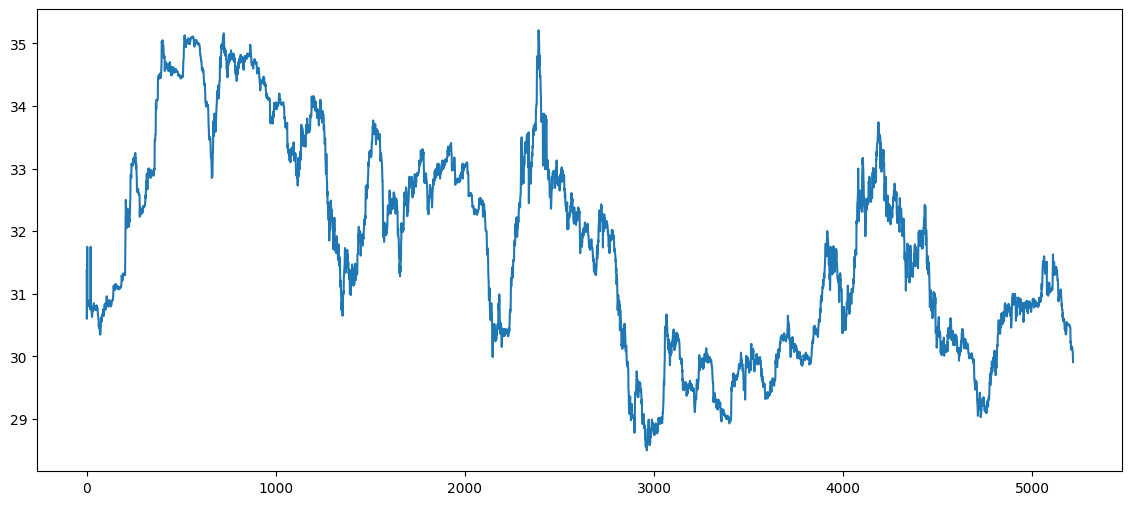

In [30]:
plt.figure(figsize=(14,6))
plt.plot(rates['TAIWAN - NEW TAIWAN DOLLAR/US$'])

In [29]:
#AD Fuller test
# SARIMA requires stationary data
# Detremines (d,D) component and if data is stationary
# if p-value > 0.05 significsnce level, then data isn't stationary, requires differncing

test_fuller = adfuller(rates["TAIWAN - NEW TAIWAN DOLLAR/US$"])

In [40]:
def adfuller_test(exrates):
    result = adfuller(exrates)
    labels = ["ADF Test Statistic",'p-value',"#Lags Used","No. of observations"]
    for value,label in zip(result, labels):
        print(label,':',str(value))

    if result[1] <= 0.05:
        print("Strong Evidence against Ho,reject the null hypothesis. No unit root and is stationary")
    else:
        print("Weak Evidence against H1, time series has a unit root, it is non-stationary ")

In [28]:
adfuller_test(rates["TAIWAN - NEW TAIWAN DOLLAR/US$"])

ADF Test Statistic : -2.294358499550666
p-value : 0.1737939239140434
#Lags Used : 30
No. of observations : 5186
Weak Evidence against H1, time series has a unit root, it is non-stationary 


In [41]:
#Differencing to make data stationary

rates["Seasonal First Difference"] = rates["TAIWAN - NEW TAIWAN DOLLAR/US$"]- rates["TAIWAN - NEW TAIWAN DOLLAR/US$"].shift(12)
rates.head()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Seasonal First Difference
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,43.55,...,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97,NaN
1,2000-01-04,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13,NaN
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,43.55,...,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10,NaN
3,2000-01-06,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,43.55,...,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62,NaN
4,2000-01-07,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,43.55,...,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30,NaN


In [42]:
adfuller_test(rates['Seasonal First Difference'].dropna())

ADF Test Statistic : -10.64179977413199
p-value : 4.908339820718867e-19
#Lags Used : 33
No. of observations : 5171
Strong Evidence against Ho,reject the null hypothesis. No unit root and is stationary


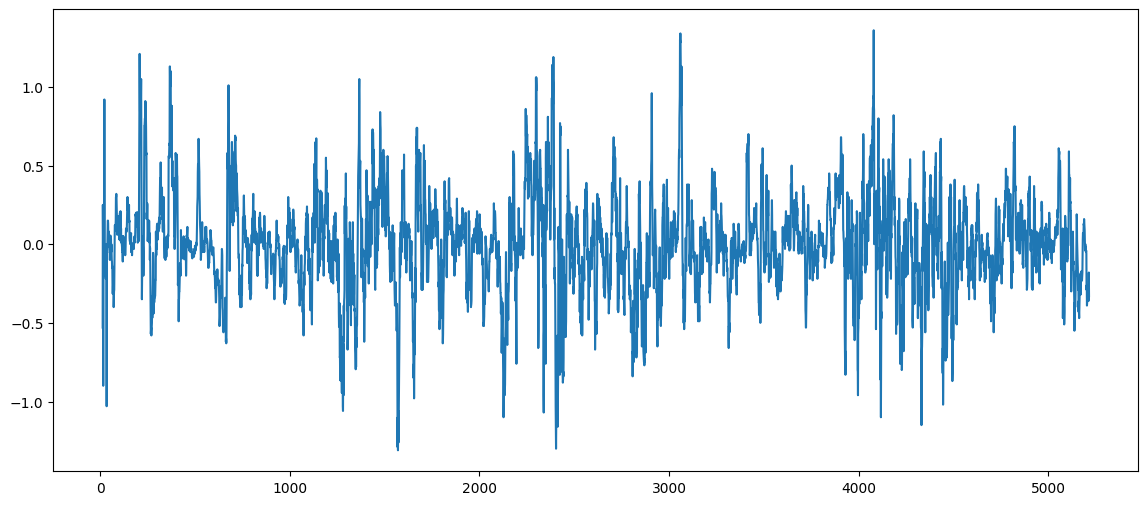

In [43]:
#visualising stationary data
plt.figure(figsize=(14,6))
plt.plot(rates["Seasonal First Difference"])

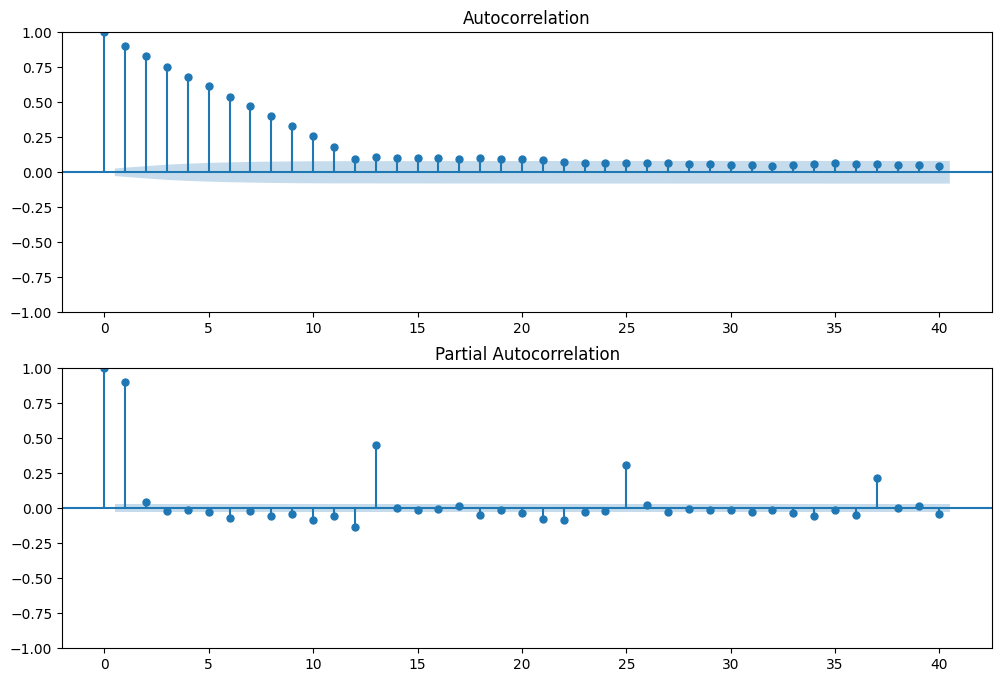

In [44]:
# ACF/PACF plot
# Measures similarity between data points at time intervals
# Determines (p, q, P, Q) via respective PACF and ACF plots
# if differenced plot 'seasonal first difference' feature
import statsmodels.api as sm

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig2 = sm.graphics.tsa.plot_acf(rates['Seasonal First Difference'].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(rates['Seasonal First Difference'].iloc[13:],lags=40,ax=ax2)

In [45]:
#Currency Orders:
#Australia:(4,1,10)
#Euro:(4,1,10)
#NZ:(4,1,10)
#UK:(5,1,10)
#Brazil:(7,1,11)
#Canada:(8,1,9)
#China:(4,1,11)
#HK:(1,0,11)
#India:(7,1,11)
#Korea:(5,1,9)
#Mexico:(4,1,10)
#South Africa:(4,1,9)
#Singapore:(6,1,10)
#Denmark:(4,1,10)
#Japan:(4,1,10)
#Malaysia:(5,1,11)
#Norway:(4,1,10)
#Sweden:(4,1,10)
#Srilanka:(5,1,10)
#Switzerland:(4,1,10)
#Taiwan:(5,1,11)
#Thailand:(4,1,11)

In [21]:
#seasonal extension of ARIMA in format (p,d,q)(P,D,Q)m:
# p/P = no. of autoregressive components found in PACF
# d/D = differencing/integration values
# q/Q = moving average components found in ACF
# m = no. of seasonal values

import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(rates["TAIWAN - NEW TAIWAN DOLLAR/US$"], order=(5,1,11),seasonal_order=(1,1,1,12))
sarima_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
print(sarima_fit.summary())

                                       SARIMAX Results                                       
Dep. Variable:        TAIWAN - NEW TAIWAN DOLLAR/US$   No. Observations:                 5217
Model:             SARIMAX(5, 1, 11)x(1, 1, [1], 12)   Log Likelihood                4761.182
Date:                               Wed, 01 Jul 2026   AIC                          -9484.365
Time:                                       20:12:20   BIC                          -9359.778
Sample:                                            0   HQIC                         -9440.787
                                              - 5217                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1501      6.515     -0.023      0.982     -12.920      12.620
ar.L2      

In [23]:
# Train/test split
#use 'seasonal first difference' if differenced
test_size = 10
train_data = rates['Seasonal First Difference'][:-test_size]
test_data = rates['Seasonal First Difference'][-test_size:]

In [24]:
# Train SARIMA model on training data
sarima_model = sm.tsa.statespace.SARIMAX(train_data,
                       order=(5, 1, 11),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
# Forecast for the test period
forecast = sarima_fit.get_forecast(steps=test_size)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

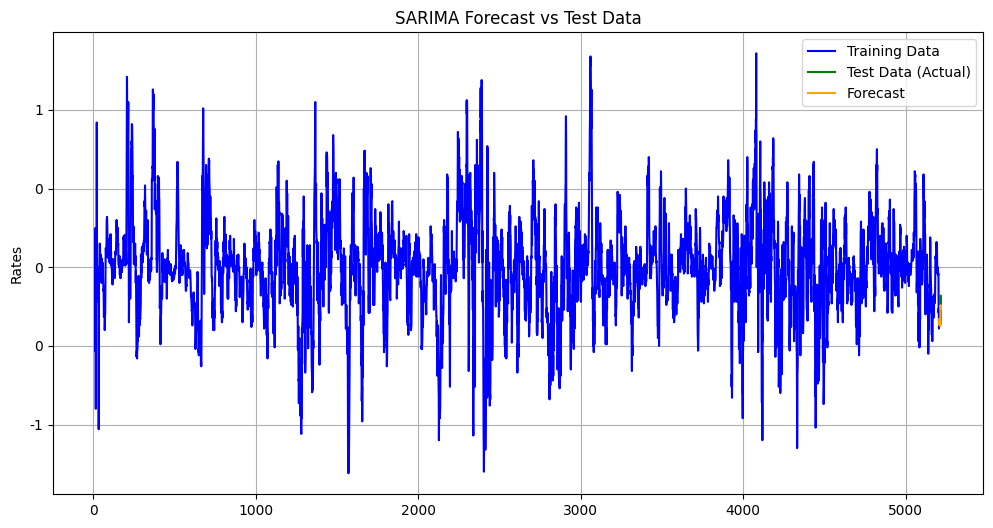

In [26]:
#visuals
plt.figure(figsize=(12, 6))

plt.plot(train_data, label='Training Data', color='blue')
plt.plot(test_data, label='Test Data (Actual)', color='green')
plt.plot(test_data.index, forecast_mean, label='Forecast', color='orange')

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
plt.title('SARIMA Forecast vs Test Data')
plt.ylabel('Rates')
plt.legend()
plt.grid()
plt.show()

In [27]:
#Evaluation Metrics
mae = mean_absolute_error(test_data, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_data, forecast_mean))
mape = np.mean(np.abs((test_data - forecast_mean) / test_data)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 0.03
Root Mean Squared Error (RMSE): 0.04
Mean Absolute Percentage Error (MAPE): 10.40%


In [46]:
#saving model
import pickle

In [47]:
with open('Taiwan_model', 'wb') as f:
  pickle.dump(model, f)